<a href="https://colab.research.google.com/github/ashbun23/IOD/blob/Capstone/capstoneproject_ashutoshshukla_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
%matplotlib inline

In [36]:
mobile = pd.read_csv('ndtv_data_final.csv')

In [37]:
mobile.head()

,Name,Brand,Model,Battery capacity (mAh),Screen size (inches),Touchscreen,Resolution x,Resolution y,Processor,RAM (MB),...,Rear camera,Front camera,Operating system,Wi-Fi,Bluetooth,GPS,Number of SIMs,3G,4G/ LTE,Price
0,OnePlus 7T Pro McLaren Edition,OnePlus,7T Pro McLaren Edition,4085,6.67,Yes,1440,3120,8,12000,...,48.0,16.0,Android,Yes,Yes,Yes,2,Yes,Yes,58998
1,Realme X2 Pro,Realme,X2 Pro,4000,6.50,Yes,1080,2400,8,6000,...,64.0,16.0,Android,Yes,Yes,Yes,2,Yes,Yes,27999
2,iPhone 11 Pro Max,Apple,iPhone 11 Pro Max,3969,6.50,Yes,1242,2688,6,4000,...,12.0,12.0,iOS,Yes,Yes,Yes,2,Yes,Yes,106900
3,iPhone 11,Apple,iPhone 11,3110,6.10,Yes,828,1792,6,4000,...,12.0,12.0,iOS,Yes,Yes,Yes,2,Yes,Yes,62900
4,LG G8X ThinQ,LG,G8X ThinQ,4000,6.40,Yes,1080,2340,8,6000,...,12.0,32.0,Android,Yes,Yes,Yes,1,No,No,49990


In [38]:
mobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    1359 non-null   object 
 1   Brand                   1359 non-null   object 
 2   Model                   1359 non-null   object 
 3   Battery capacity (mAh)  1359 non-null   int64  
 4   Screen size (inches)    1359 non-null   float64
 5   Touchscreen             1359 non-null   object 
 6   Resolution x            1359 non-null   int64  
 7   Resolution y            1359 non-null   int64  
 8   Processor               1359 non-null   int64  
 9   RAM (MB)                1359 non-null   int64  
 10  Internal storage (GB)   1359 non-null   float64
 11  Rear camera             1359 non-null   float64
 12  Front camera            1359 non-null   float64
 13  Operating system        1359 non-null   object 
 14  Wi-Fi                   1359 non-null   

In [39]:
mobile.describe()

,Battery capacity (mAh),Screen size (inches),Resolution x,Resolution y,Processor,RAM (MB),Internal storage (GB),Rear camera,Front camera,Number of SIMs,Price
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,2938.489330,5.291310,811.543046,1490.777778,5.551141,2488.777778,30.654864,12.070199,7.037969,1.833701,11465.825607
std,873.514133,0.671357,270.707271,557.780120,2.196562,1664.440386,36.950241,8.948337,6.295448,0.374457,13857.497077
min,1010.000000,2.400000,240.000000,320.000000,1.000000,64.000000,0.064000,0.000000,0.000000,1.000000,494.000000
25%,2300.000000,5.000000,720.000000,1280.000000,4.000000,1000.000000,8.000000,8.000000,2.000000,2.000000,4763.500000
50%,3000.000000,5.200000,720.000000,1280.000000,4.000000,2000.000000,16.000000,12.200000,5.000000,2.000000,6999.000000
75%,3500.000000,5.700000,1080.000000,1920.000000,8.000000,3000.000000,32.000000,13.000000,8.000000,2.000000,11999.000000
max,6000.000000,7.300000,2160.000000,3840.000000,10.000000,12000.000000,512.000000,108.000000,48.000000,3.000000,174990.000000


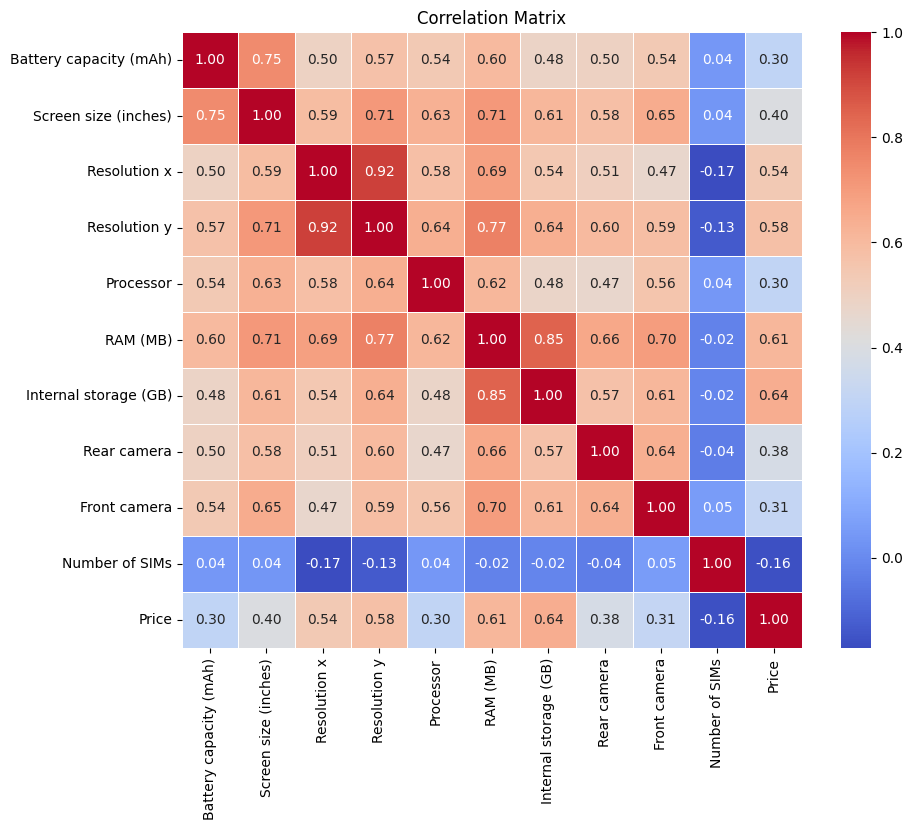

In [40]:
#Draw the correlation matrix.
numeric_columns=mobile.select_dtypes(include=['float64','int64'])

#Calculate the correlation matrix
correlation_matrix=numeric_columns.corr()

#Set up matplotlib figure
plt.figure(figsize=(10,8))

#Create a heatmap using seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

#Show the plot
plt.title('Correlation Matrix')
plt.show()

In [41]:
mobile_without_target = numeric_columns.drop(['Price'], axis=1)

In [42]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(mobile_without_target)

KMeans(n_clusters=2)

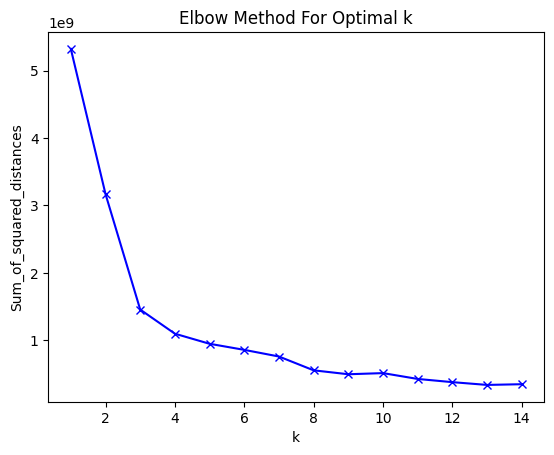

In [43]:
# Initialize KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model
kmeans.fit(mobile_without_target)

# Get the cluster labels
labels = kmeans.labels_

# Add the cluster labels to the original dataframe
mobile['Cluster'] = labels

Sum_of_squared_distances = []
K = range(1,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(mobile_without_target)
    Sum_of_squared_distances.append(km.inertia_)

plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true s

Accuracy: 0.0196078431372549
Classification Report:
              precision    recall  f1-score   support

         994       0.00      0.00      0.00         1
        1999       0.00      0.00      0.00         5
        2199       0.00      0.00      0.00         2
        2222       0.00      0.00      0.00         1
        2340       0.00      0.00      0.00         1
        2399       0.00      0.00      0.00         2
        2499       0.00      0.00      0.00         2
        2590       0.00      0.00      0.00         1
        2599       0.00      0.00      0.00         1
        2754       0.00      0.00      0.00         1
        2799       0.00      0.00      0.00         1
        2940       0.00      0.00      0.00         1
        2950       0.00      0.00      0.00         1
        2999       0.00      0.00      0.00         7
        3099       0.00      0.00      0.00         1
        3199       0.00      0.00      0.00         1
        3250       0.00      

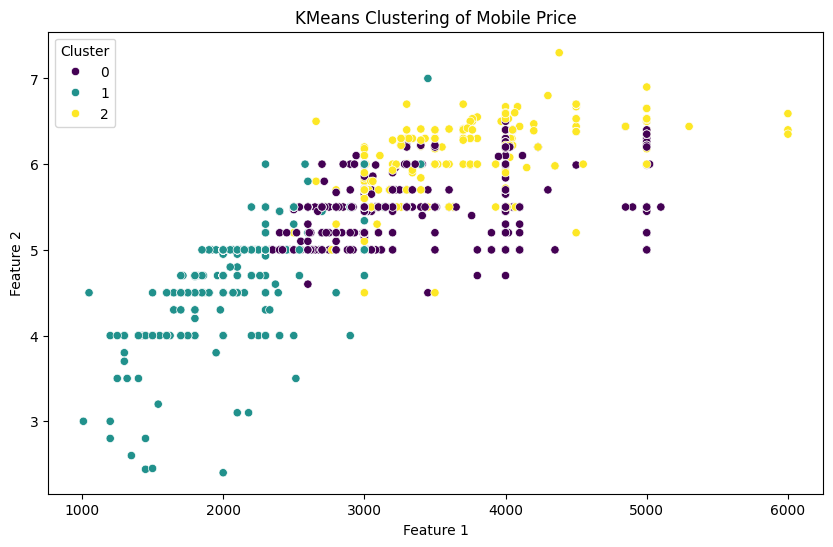

In [44]:
# Now, let's assume 'target' is your target variable for supervised learning
y = mobile['Price']
X = mobile_without_target



# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)

# Visualize the clusters (assuming you have at least two features)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=mobile_without_target.iloc[:, 0], y=mobile_without_target.iloc[:, 1], hue=labels, palette='viridis')
plt.title('KMeans Clustering of Mobile Price')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(title='Cluster')
plt.show()

In [45]:
X, y = make_classification(n_samples=1000, n_features=4,
                           n_informative=2, n_redundant=0,
                           random_state=0, shuffle=False)
clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(X, y)

RandomForestClassifier(max_depth=2, random_state=0)

ValueError: x and y must be the same size

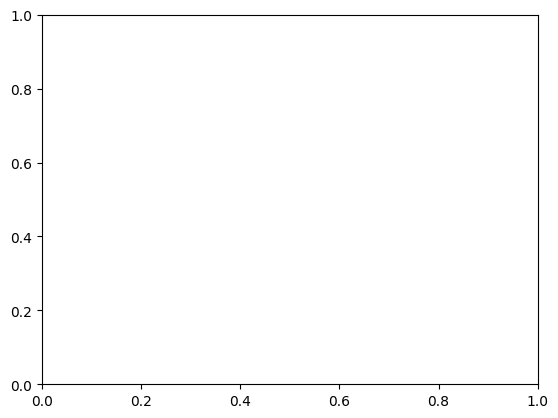

In [56]:
plt.scatter(X, y, color='blue')  # plotting real points
plt.plot(X_grid, classifier.predict(X_grid), color='green')  # plotting predicted points

plt.title("Random Forest Regression Results")
plt.xlabel('Mobile Phone Features')
plt.ylabel('Mobile Phone Price')
plt.show()

plt.title("Random Forest Regression Results")
plt.xlabel('Mobile Phone Features')
plt.ylabel('Mobile Phone Price')
plt.show()

In [48]:

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [49]:
# Fit the model to the training data:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [57]:
# Make predictions on the test data:
y_pred = rf_model.predict(X_test)
print(y_pred)

[27136.32        6265.98166667  4592.88175     4698.48833333
  2619.23       15747.09       12858.73        5476.9575
  6095.45762241  6714.5105      8039.17        6429.58166667
  5050.86983328 34360.04       15394.93933333  9833.86
  5506.58666667 10919.76333333  8699.338      13969.46
 11188.42        8504.361      18590.82333333 10810.495
 22084.83        9023.51        6995.602      45196.93
  8229.18192857  2930.96        4551.69714286 22421.85
 11505.58        6899.99133333  3661.74        5063.78983333
  6720.39712698  3655.8         4551.69714286  9913.868
  3496.72866667 32604.59        3725.01        8489.8335
 10572.46        6284.66833333 23724.27        6178.41
 14331.66666667 15776.165       2369.32       10661.9
 10494.69        6265.98166667  4402.24214286 24601.11
 16521.136       2767.07        4024.84133333  6171.77666667
 10884.99        8787.71333333 15695.36       10833.77
  7497.46       10057.86035714 27193.434      13876.97
  5095.21083333  4011.44        4200

In [54]:
# Use metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), or Root Mean Squared Error (RMSE):
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")

MAE: 4530.669148030211, MSE: 86488417.52384362, RMSE: 9299.914920247584


In [55]:
# Get insights into which features were most influential in the model’s predictions:

feature_importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)
print(importance_df)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'